import required libraries

In [2]:
#basic libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#for image precessings

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
#dataset

#for training data

data_path = "seg_train/seg_train"

In [7]:
# Getting class names

scene_classes = os.listdir(data_path)

print("Available Scene Classes:")
print("-" * 30)

for cls in scene_classes:
    print(cls)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'seg_train/seg_train'

In [8]:
import os

print(os.getcwd())

C:\Users\akash


In [9]:
import os

print(os.listdir())

['.anaconda', '.bashrc', '.bash_history', '.bash_profile', '.cache', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.eclipse', '.git', '.gitconfig', '.gitignore', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.node_repl_history', '.npmrc', '.p2', '.redhat', '.sonarlint', '.ssh', '.streamlit', '.vscode', '.vscode-shared', 'a', 'addd.py', 'adult_dataset.csv', 'anaconda3', 'anaconda_projects', 'ANN_assignment.ipynb', 'AppData', 'Application Data', 'archive (6)', 'archive (6).zip', 'assignment01_python_basics.ipynb', 'Assignment05_ANN.pdf', 'assignment07.ipynb', 'Assignment07_NLP_DL.pdf', 'assignment2_ml.ipynb', 'Assignment_1pythonbasics.ipynb', 'Assignment_Classification.pdf', 'Assignment_regression.ipynb', 'autism-dete', 'bank-additional-full.csv', 'car details v4.csv', 'Case Study Unsupervised Learning.pdf', 'CaseStudy01.ipynb', 'casestudy_one.ipynb', 'case_study1.ipynb', 'cd my-tvapp', 'citic-react', 'classification_assignme

In [10]:
import os

print(os.listdir("archive (6)"))

['seg_pred', 'seg_test', 'seg_train']


In [11]:
import os

print(os.listdir("archive (6)/seg_train"))

['seg_train']


In [12]:
data_path = "archive (6)/seg_train/seg_train"
test_path = "archive (6)/seg_test/seg_test"

In [13]:
import os

data_path = "archive (6)/seg_train/seg_train"

scene_classes = os.listdir(data_path)

print("Available Scene Classes:")
print(scene_classes)

Available Scene Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [14]:
# Counting images in each class

class_count = {}

for cls in scene_classes:

    folder_path = os.path.join(data_path, cls)

    total_images = len(os.listdir(folder_path))

    class_count[cls] = total_images

print("Number of Images in Each Class")
print("-" * 35)

for cls, count in class_count.items():
    print(f"{cls} : {count}")

Number of Images in Each Class
-----------------------------------
buildings : 2191
forest : 2271
glacier : 2404
mountain : 2512
sea : 2274
street : 2382


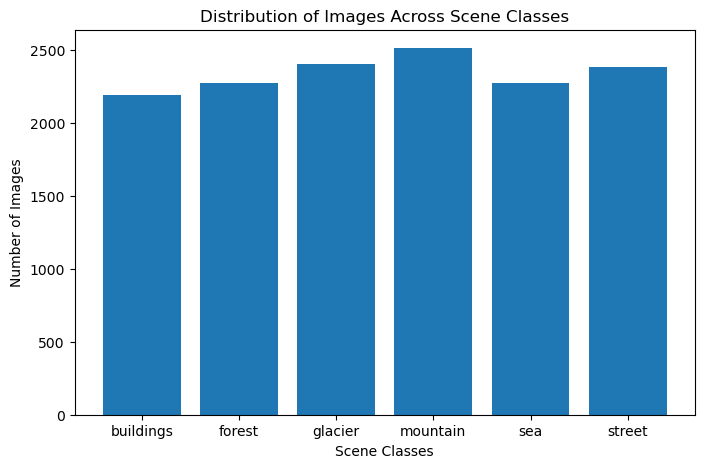

In [15]:
# Visualizing the number of images in each class

plt.figure(figsize=(8,5))

plt.bar(
    class_count.keys(),
    class_count.values()
)

plt.title("Distribution of Images Across Scene Classes")
plt.xlabel("Scene Classes")
plt.ylabel("Number of Images")

plt.show()

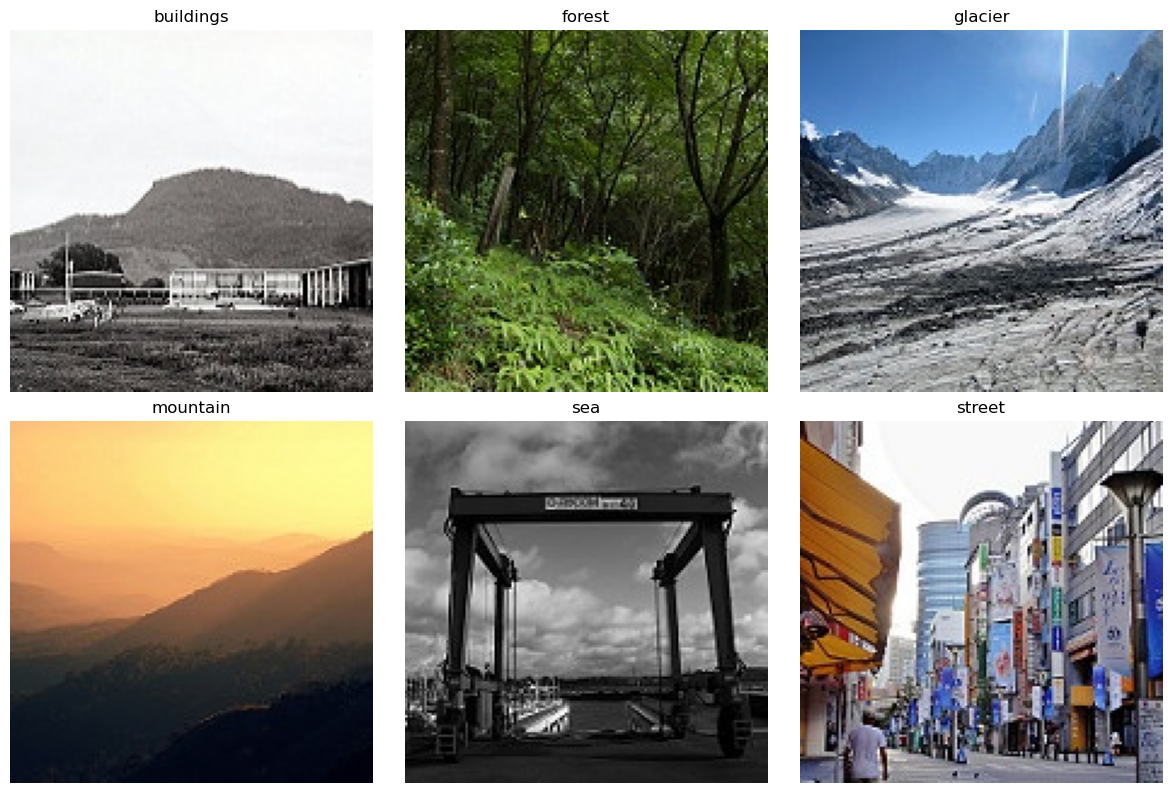

In [16]:
# Displaying one sample image from each category

plt.figure(figsize=(12,8))

for i, cls in enumerate(scene_classes):

    image_name = os.listdir(
        os.path.join(data_path, cls)
    )[0]

    image_path = os.path.join(
        data_path,
        cls,
        image_name
    )

    img = plt.imread(image_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
#checking image dimension

sample_class = scene_classes[0]

sample_image = os.listdir(
    os.path.join(data_path, sample_class)
)[0]

sample_path = os.path.join(
    data_path,
    sample_class,
    sample_image
)
img= plt.imread(sample_path)

print("Image shape: ", img.shape)

Image shape:  (150, 150, 3)


In [18]:
#defining uniform image for cnn model

IMG_HEIGHT = 150
IMG_WIDTH = 150

print("target image size:")
print((IMG_HEIGHT,IMG_WIDTH))

target image size:
(150, 150)


In [19]:
#crearing training and validation dataset

from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

#training the dataset

train_data = data_generator.flow_from_directory(
    data_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

#validate dataset

val_data = data_generator.flow_from_directory(
    data_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [21]:
#load test dataset

test_generator = ImageDataGenerator(
    rescale=1./255
)

test_data = test_generator.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [22]:
print("Dataset Summary")
print("-" * 30)

print("Training Images   :", train_data.samples)
print("Validation Images :", val_data.samples)
print("Testing Images    :", test_data.samples)

Dataset Summary
------------------------------
Training Images   : 11230
Validation Images : 2804
Testing Images    : 3000


#analytical question 1:
## Analytical Question 1

Different lighting conditions can change how a scene looks, while changes in viewpoint can affect the visibility and appearance of important features. Also, if some classes have more images than others, the model may become biased toward those classes. These challenges can reduce the overall accuracy and performance of the classification model.

## task 2

In [23]:
#creating a data generator with augmented techniques

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.20
)

In [25]:
#Loading training images with augmentation

train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 11230 images belonging to 6 classes.


In [26]:
# loading validation images

val_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2804 images belonging to 6 classes.


In [27]:
# displaying class labels

print("Class Mapping")
print("-" * 20)

print(train_data.class_indices)

Class Mapping
--------------------
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


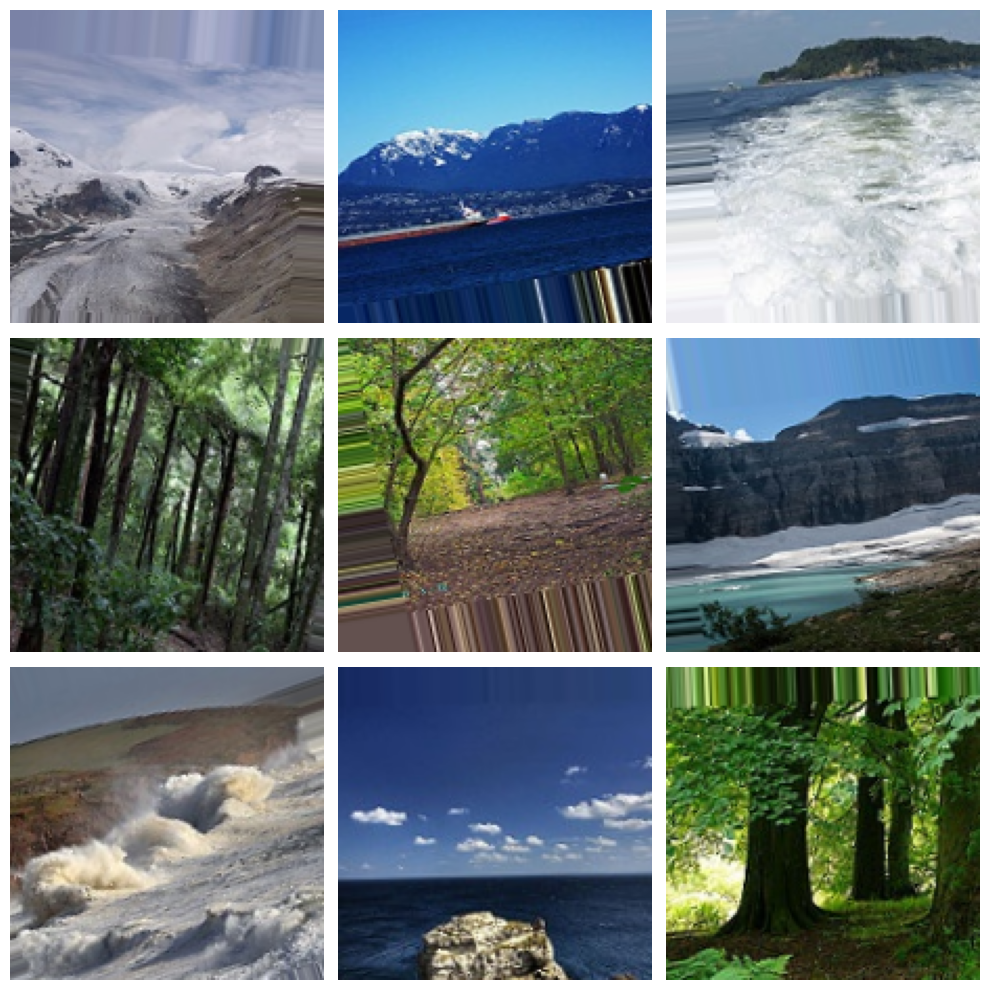

In [28]:
#displaying augmented images

images, labels = next(train_data)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [29]:
# checking shape of one batch

images, labels = next(train_data)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 150, 150, 3)
Label Batch Shape : (32, 6)


## Analytical question 2

Data augmentation helps reduce overfitting by creating different versions of the same image using techniques like rotation, flipping, zooming, and shifting. This increases the variety of training data and helps the model learn important features instead of memorizing images. As a result, the model can perform better on new and unseen data

## task 3

In [30]:
#import CNN layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [31]:

#bilding a CNN model

cnn_model = Sequential()

#first convolution block

cnn_model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(150,150,3)
    )
)

cnn_model.add(
    MaxPooling2D(pool_size=(2,2))
)

#second convolution Block

cnn_model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

cnn_model.add(
    MaxPooling2D(pool_size=(2,2))
)

#third convolution Block

cnn_model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)

cnn_model.add(
    MaxPooling2D(pool_size=(2,2))
)

#convert feature maps into a single vector

cnn_model.add(Flatten())

#fully connected layer

cnn_model.add(
    Dense(
        256,
        activation='relu'
    )
)

#dropout to reduce overfitting

cnn_model.add(
    Dropout(0.5)
)

#output layer

cnn_model.add(
    Dense(
        6,
        activation='softmax'
    )
)

In [32]:
#model architecture

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#compile CNN model

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
#training the model

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 325s 919ms/step - accuracy: 0.5107 - loss: 1.2163 - val_accuracy: 0.6355 - val_loss: 0.9527
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 190s 541ms/step - accuracy: 0.6258 - loss: 0.9839 - val_accuracy: 0.6730 - val_loss: 0.8635
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.6709 - loss: 0.8744 - val_accuracy: 0.7058 - val_loss: 0.7975
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 196s 558ms/step - accuracy: 0.7061 - loss: 0.7904 - val_accuracy: 0.7475 - val_loss: 0.7012
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 199s 565ms/step - accuracy: 0.7321 - loss: 0.7418 - val_accuracy: 0.7168 - val_loss: 0.7192
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 196s 558ms/step - accuracy: 0.7463 - loss: 0.6975 - val_accuracy: 0.7821 - val_loss: 0.6234
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 184s 524ms/step - accuracy: 0.7598 - loss: 0.6767 - val_accuracy: 0.7728 - val_loss: 0.6250
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 520ms/step - accuracy: 0.7647 -

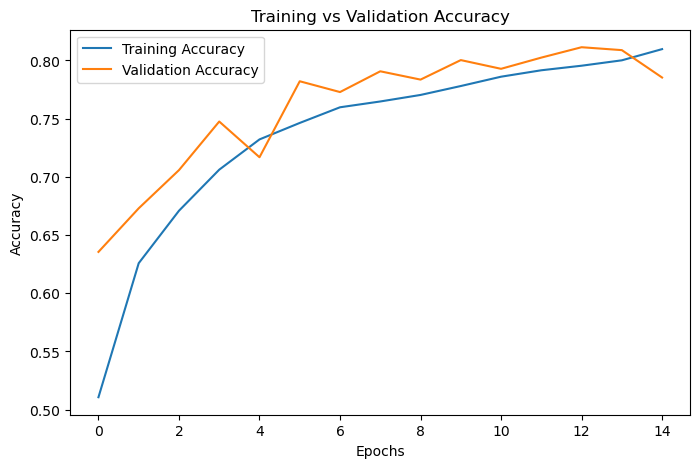

In [36]:
# Plotting training and validation accuracy

plt.figure(figsize=(8,5))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

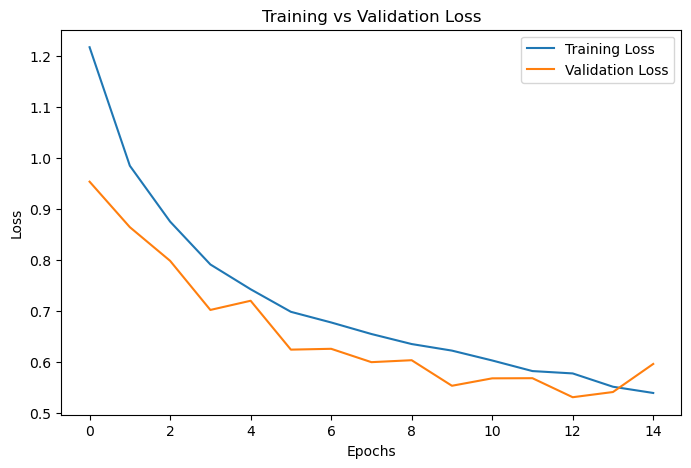

In [37]:
#plotting training and validation loss

plt.figure(figsize=(8,5))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
#saving the trained CNN model

cnn_model.save("scene_classifier_cnn.keras")

## Analytical question 3


Convolution helps a CNN identify important features in an image, such as edges, shapes, and textures, while pooling reduces the size of the feature maps and keeps the most important information. This makes the model faster, helps reduce overfitting, and improves its ability to recognize objects even when their position changes slightly. Together, convolution and pooling help the CNN learn useful features and classify images more accurately.


## Task 4

In [41]:
#evaluating the CNN model on unseen test images

test_loss, test_accuracy = cnn_model.evaluate(test_data)
print("\nModel Evaluation Results")
print("-" * 30)


print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.8190 - loss: 0.5285

Model Evaluation Results
------------------------------
Test Loss     : 0.5285
Test Accuracy : 0.8190


In [43]:
#generating predictions on test images

predictions = cnn_model.predict(test_data)
print("Prediction shape :", predictions.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step
Prediction shape : (3000, 6)


In [44]:
#converting probabilities into class labels

predicted_labels = np.argmax(
    predictions,
    axis=1
)
true_labels = test_data.classes
print("Total Test Images :", len(true_labels))

Total Test Images : 3000


In [45]:
#classidication report

from sklearn.metrics import classification_report
class_names = list(
    test_data.class_indices.keys()
)
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)
print(report)

              precision    recall  f1-score   support

   buildings       0.86      0.80      0.83       437
      forest       0.91      0.99      0.95       474
     glacier       0.81      0.73      0.77       553
    mountain       0.82      0.67      0.74       525
         sea       0.70      0.91      0.79       510
      street       0.86      0.84      0.85       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



In [46]:
#generate confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    true_labels,
    predicted_labels
)
print(cm)

[[349   7   2   6  12  61]
 [  1 469   0   3   1   0]
 [  5   5 405  45  90   3]
 [  4   2  76 351  92   0]
 [ 11   3  11  19 463   3]
 [ 36  29   5   4   7 420]]


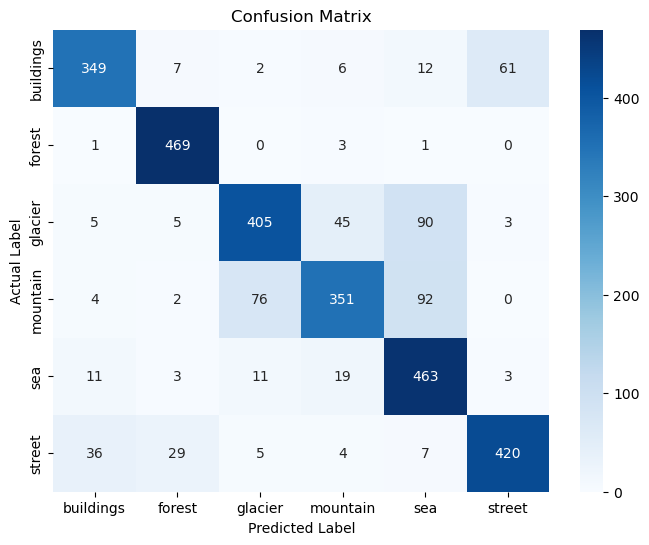

In [47]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [48]:
#calculating accuracy
from sklearn.metrics import accuracy_score

overall_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)
print(
    f"Overall Accuracy : {overall_accuracy:.4f}"
)

Overall Accuracy : 0.8190


In [49]:
#display class mapping

print("Class Mapping")
print("-" * 20)
for label, value in test_data.class_indices.items():
    print(f"{value} --> {label}")

Class Mapping
--------------------
0 --> buildings
1 --> forest
2 --> glacier
3 --> mountain
4 --> sea
5 --> street


## Analytical question 4

he confusion matrix shows that some classes are often confused because they have similar features. For example, glacier and mountain images may look alike due to snow and rocks, while buildings and streets can share similar structures. This makes it harder for the model to classify them correctly.

## task 5

In [52]:
#Identify incorrectly classified samples. 

misclassified_indices = np.where(
    predicted_labels != true_labels
)[0]
print("Total Misclassified Images :", len(misclassified_indices))

Total Misclassified Images : 543


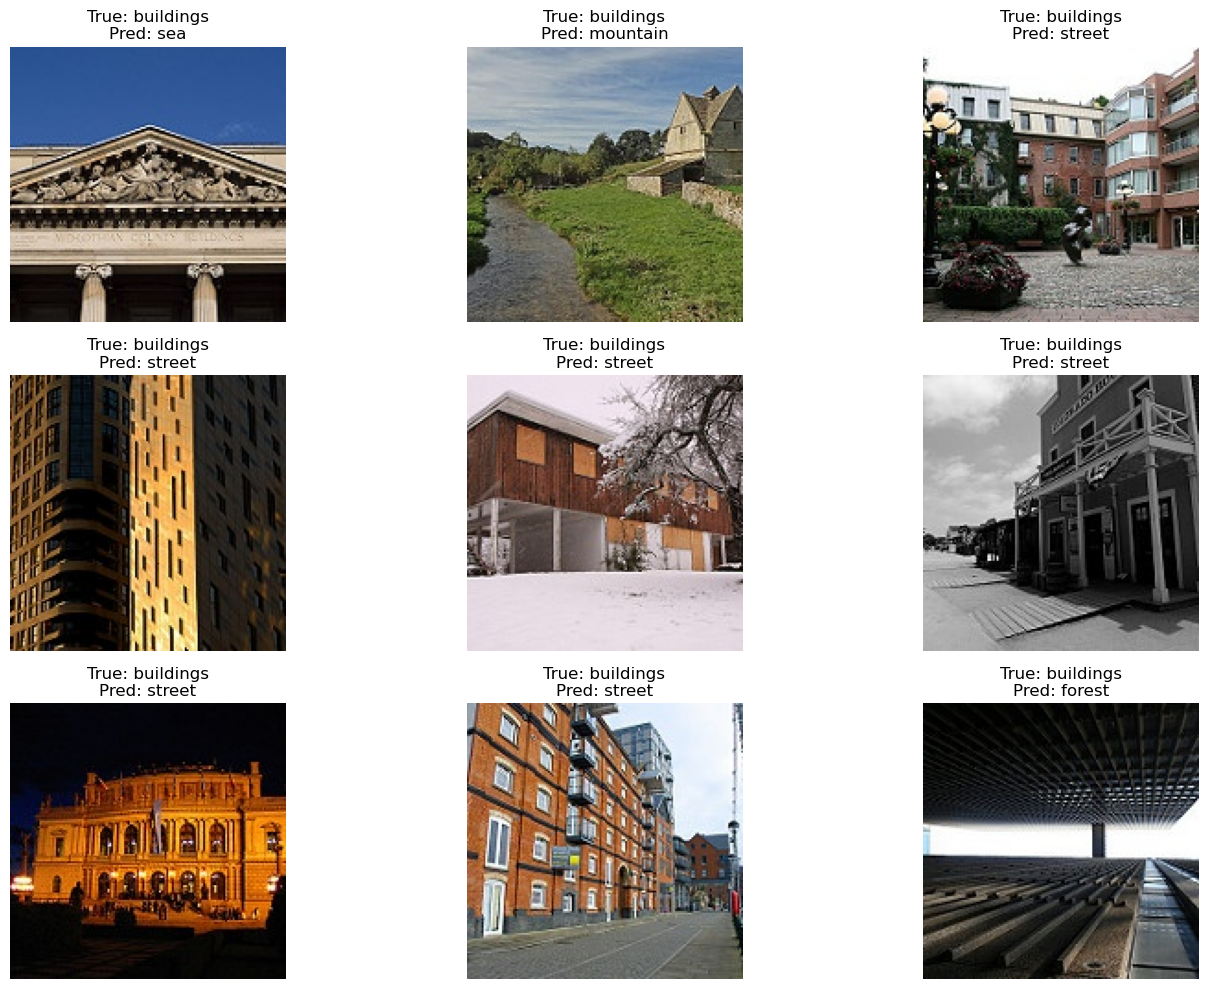

In [53]:
#displaying a few misclassified images

plt.figure(figsize=(15,10))
for i, idx in enumerate(misclassified_indices[:9]):
    plt.subplot(3,3,i+1)
    image_path = test_data.filepaths[idx]
    img = plt.imread(image_path)
    plt.imshow(img)
    true_class = class_names[
        true_labels[idx]
    ]
    predicted_class = class_names[
        predicted_labels[idx]
    ]

    plt.title(
        f"True: {true_class}\nPred: {predicted_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [55]:
# checking common misclassification pairs

misclassification_summary = {}

for i in misclassified_indices:
    true_class = class_names[true_labels[i]]
    predicted_class = class_names[predicted_labels[i]]
    pair = f"{true_class} → {predicted_class}"
    if pair in misclassification_summary:
        misclassification_summary[pair] += 1
    else:
        misclassification_summary[pair] = 1
sorted_errors = sorted(
    misclassification_summary.items(),
    key=lambda x: x[1],
    reverse=True
)
print("Most Common Misclassifications")
print("-" * 40)
for pair, count in sorted_errors[:10]:
    print(pair, ":", count)

Most Common Misclassifications
----------------------------------------
mountain → sea : 92
glacier → sea : 90
mountain → glacier : 76
buildings → street : 61
glacier → mountain : 45
street → buildings : 36
street → forest : 29
sea → mountain : 19
buildings → sea : 12
sea → glacier : 11


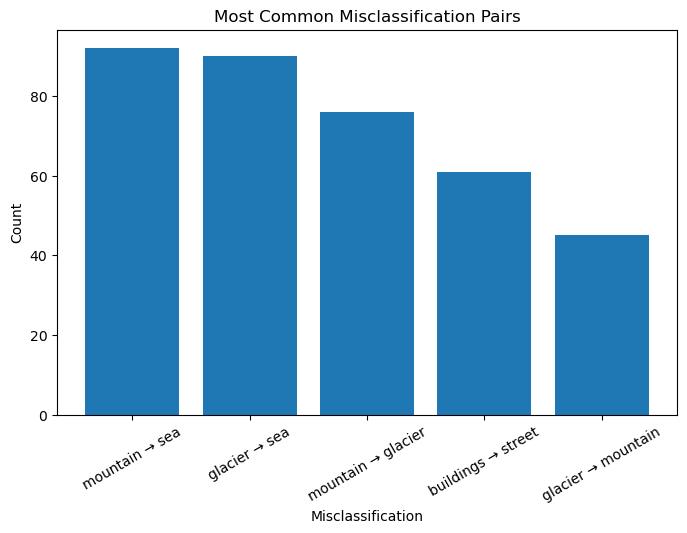

In [56]:
# Plotting common errors

top_errors = sorted_errors[:5]
error_names = [item[0] for item in top_errors]
error_counts = [item[1] for item in top_errors]
plt.figure(figsize=(8,5))
plt.bar(
    error_names,
    error_counts
)
plt.xticks(rotation=30)
plt.title("Most Common Misclassification Pairs")
plt.xlabel("Misclassification")
plt.ylabel("Count")
plt.show()

## Analytical question 5

The model sometimes makes mistakes when different scene categories look similar. For example, glacier and mountain images may have similar features, while buildings and streets can share common structures. Changes in lighting, weather, or image quality can also make classification more difficult.

## Task 6

In [57]:
# importing transfer learning model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

In [58]:
#loading MobileNetV2 without the top classification layer

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

#freezing pre-trained layers

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [59]:
# Adding custom classification layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(
    256,
    activation='relu'
)(x)
x = Dropout(0.5)(x)
output = Dense(
    6,
    activation='softmax'
)(x)
improved_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [60]:
improved_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 150, 150, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 75, 75, 32)        │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 75, 75, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 75, 75, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 75, 75, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 75, 75, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 75, 75, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 75, 75, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 75, 75, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 75, 75, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 75, 75, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 75, 75, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 77, 77, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 38, 38, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [61]:
#compiling the improved model

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
#training the improved model

history_improved = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 226s 629ms/step - accuracy: 0.7784 - loss: 0.6066 - val_accuracy: 0.8524 - val_loss: 0.4042
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.8335 - loss: 0.4597 - val_accuracy: 0.8645 - val_loss: 0.3684
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 175s 500ms/step - accuracy: 0.8360 - loss: 0.4382 - val_accuracy: 0.8691 - val_loss: 0.3584
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 169s 481ms/step - accuracy: 0.8492 - loss: 0.4149 - val_accuracy: 0.8713 - val_loss: 0.3577
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 167s 476ms/step - accuracy: 0.8465 - loss: 0.4072 - val_accuracy: 0.8677 - val_loss: 0.3566
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 170s 484ms/step - accuracy: 0.8534 - loss: 0.3957 - val_accuracy: 0.8745 - val_loss: 0.3458
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 522ms/step - accuracy: 0.8550 - loss: 0.3871 - val_accuracy: 0.8695 - val_loss: 0.3426
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.8570 -

In [63]:
# Evaluating the improved model

improved_loss, improved_accuracy = improved_model.evaluate(
    test_data
)
print("\nImproved Model Performance")
print("-" * 35)
print(f"Test Loss     : {improved_loss:.4f}")
print(f"Test Accuracy : {improved_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 318ms/step - accuracy: 0.8933 - loss: 0.2795

Improved Model Performance
-----------------------------------
Test Loss     : 0.2795
Test Accuracy : 0.8933


In [64]:
# Comparing model performances

print("Performance Comparison")
print("-" * 35)
print(f"Original CNN Accuracy  : {test_accuracy:.4f}")
print(f"Improved Model Accuracy: {improved_accuracy:.4f}")

accuracy_gain = (
    improved_accuracy - test_accuracy
) * 100

print(f"Accuracy Improvement   : {accuracy_gain:.2f}%")

Performance Comparison
-----------------------------------
Original CNN Accuracy  : 0.8190
Improved Model Accuracy: 0.8933
Accuracy Improvement   : 7.43%


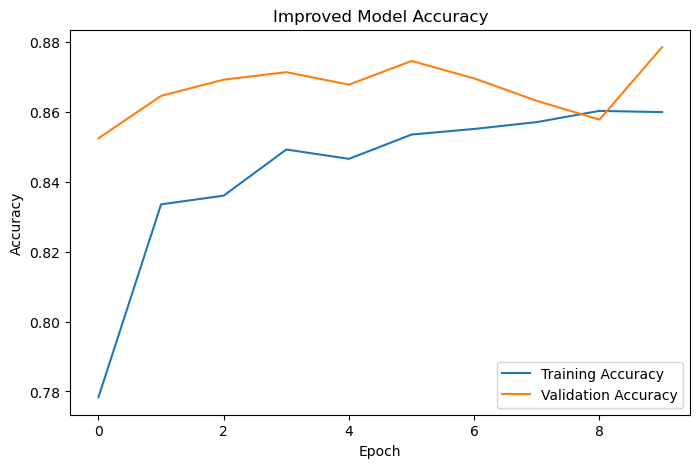

In [65]:
#visualize training model


plt.figure(figsize=(8,5))
plt.plot(
    history_improved.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history_improved.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Improved Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [67]:
# Saving the refined model

improved_model.save(
    "intel_scene_classifier.keras"
)

## Analytical Question 6

The refined model performed better than the original CNN and achieved higher accuracy. Using MobileNetV2 helped the model learn image features more effectively and improve classification results. However, the model is more complex and may require more memory and processing time. Even with these drawbacks, the improved accuracy makes it a better choice for scene classification.